In [1]:
import matplotlib.pyplot as plt
import numpy as np
from model_ranking.utils import load_h5, get_roi_slice

INFO: P [MainThread] 2026-08-08 13:18:35,133 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# EPFL

In [2]:
E_raw_data_path = "/g/kreshuk/talks/data/EPFL/resized_pixels/test.h5"

In [3]:
E_raw = load_h5(E_raw_data_path, "raw")
E_gt = load_h5(E_raw_data_path, "labels")
print(E_raw.shape, E_gt.shape)

(125, 480, 640) (125, 480, 640)


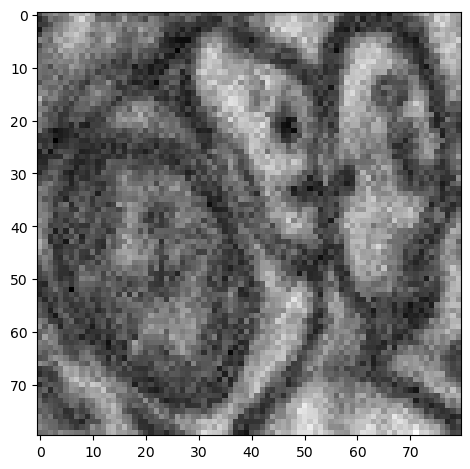

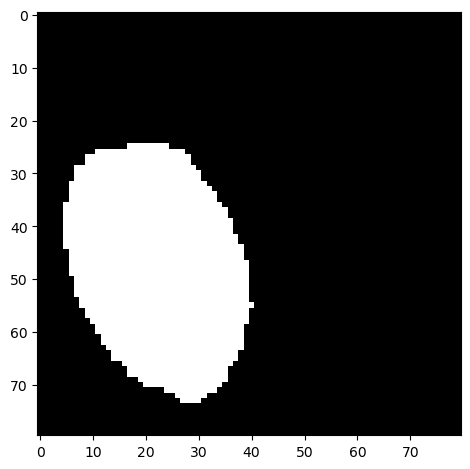

In [24]:
slice_id = 60

tick_fontsize = 18

_ = plt.imshow(E_raw[slice_id, :80, 270:350].squeeze(), cmap='gray')
#_ = plt.axis("off")
# plt.xticks(fontsize=tick_fontsize)
# plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()
#plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/EPFL_classification_empty_raw.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(E_gt[slice_id, :80, 270:350].squeeze(), cmap='gray')
#_ = plt.axis("off")
# plt.xticks(fontsize=tick_fontsize)
# plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()
#plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/EPFL_classification_empty_label.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

# Hmito

In [10]:
Hm_raw_data_path = "/g/kreshuk/talks/data/Hmito/test_converted.h5"

In [11]:
Hm_raw = load_h5(Hm_raw_data_path, "raw")
Hm_gt = load_h5(Hm_raw_data_path, "labels")
print(Hm_raw.shape)

(150, 4096, 4096)


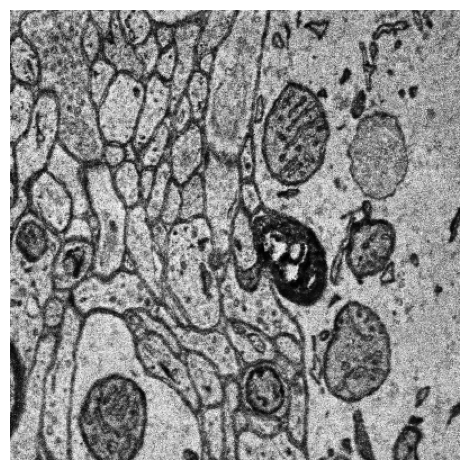

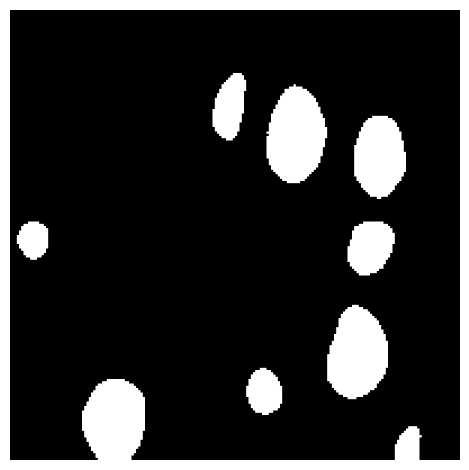

In [12]:
# slice_id = [50, 100:580, :640]

tick_fontsize = 14

_ = plt.imshow(Hm_raw[50, 600:1000, 100:500].squeeze(), cmap='gray')
_ = plt.axis("off")
# plt.xticks(fontsize=tick_fontsize)
# plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/Hmito_raw_full.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(Hm_gt[50, 600:1000, 100:500].squeeze(), cmap='gray')
_ = plt.axis("off")
# plt.xticks(fontsize=tick_fontsize)
# plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/Hmito_label_full.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

# Rmito

In [13]:
Rm_raw_data_path = "/g/kreshuk/talks/data/Rmito/test_converted.h5"

In [14]:
Rm_raw = load_h5(Rm_raw_data_path, "raw")
Rm_gt = load_h5(Rm_raw_data_path, "labels")
print(Rm_raw.shape)

(150, 4096, 4096)


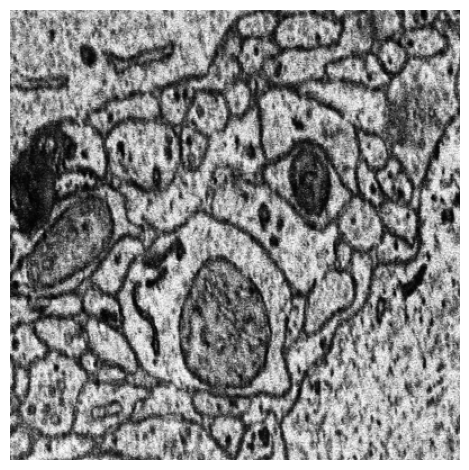

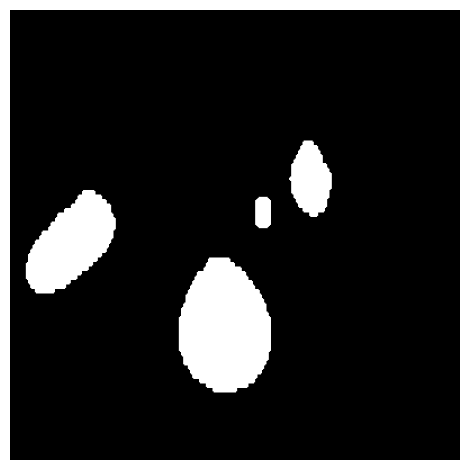

In [15]:
# slice_id = [50, 100:580, :640]

tick_fontsize = 14

_ = plt.imshow(Rm_raw[50, 200:600, 0:400].squeeze(), cmap='gray')
_ = plt.axis("off")
# plt.xticks(fontsize=tick_fontsize)
# plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/Rmito_raw.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(Rm_gt[50, 200:600, 0:400].squeeze(), cmap='gray')
_ = plt.axis("off")
# plt.xticks(fontsize=tick_fontsize)
# plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/Rmito_label.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

# VNC

In [16]:
V_raw_data_path = "/g/kreshuk/talks/data/VNC/resized_pixels/test_converted.h5"

In [17]:
V_raw = load_h5(V_raw_data_path, "raw")
V_gt = load_h5(V_raw_data_path, "labels")
print(V_raw.shape)

(3, 589, 589)


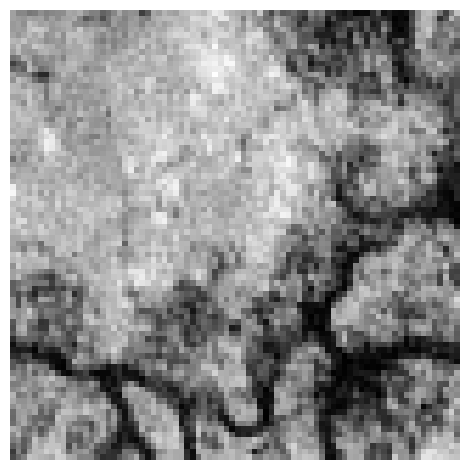

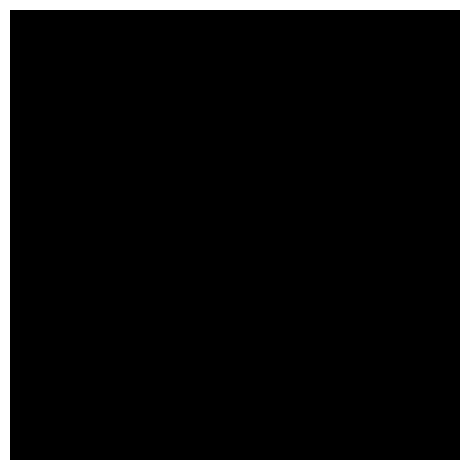

In [26]:
# slice_id = [50, 100:580, :640]

tick_fontsize = 14

_ = plt.imshow(V_raw[2, 10:90, 200:280].squeeze(), cmap='gray')
_ = plt.axis("off")
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/VNC_classification_empty_raw.png", bbox_inches="tight", pad_inches=0)
plt.show()

_ = plt.imshow(V_gt[2, 10:90, 200:280].squeeze(), cmap='gray')
_ = plt.axis("off")
# plt.xticks(fontsize=tick_fontsize)
# plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/VNC_classification_empty_label.png", bbox_inches="tight", pad_inches=0)
plt.show()

# Classification Dataset

In [ ]:
path = "/g/kreshuk/talks/data/EPFL/classification_patches/epfl_resized_01_80x80.h5"

train_patches = load_h5(path, "training")